In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
%matplotlib inline
warnings.filterwarnings('ignore')

In [4]:
data = pd.read_csv('winequality-red.csv')
data.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [5]:
data.shape

(1599, 12)

In [6]:
data.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='str')

In [7]:
data.info

<bound method DataFrame.info of       fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0               7.4             0.700         0.00             1.9      0.076   
1               7.8             0.880         0.00             2.6      0.098   
2               7.8             0.760         0.04             2.3      0.092   
3              11.2             0.280         0.56             1.9      0.075   
4               7.4             0.700         0.00             1.9      0.076   
...             ...               ...          ...             ...        ...   
1594            6.2             0.600         0.08             2.0      0.090   
1595            5.9             0.550         0.10             2.2      0.062   
1596            6.3             0.510         0.13             2.3      0.076   
1597            5.9             0.645         0.12             2.0      0.075   
1598            6.0             0.310         0.47             3.6      0.067

In [8]:
data.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [9]:
data = data.drop_duplicates()
data.shape

(1359, 12)

In [10]:
data.quality.value_counts()

quality
5    577
6    535
7    167
4     53
8     17
3     10
Name: count, dtype: int64

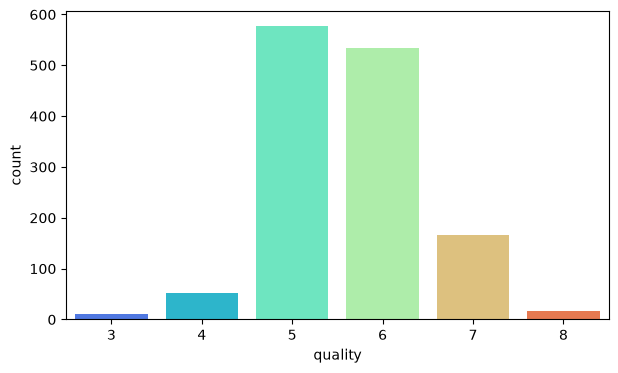

In [11]:
plt.figure(figsize=(7,4))
sns.countplot(x = 'quality' , data = data , palette = 'rainbow')
plt.show()

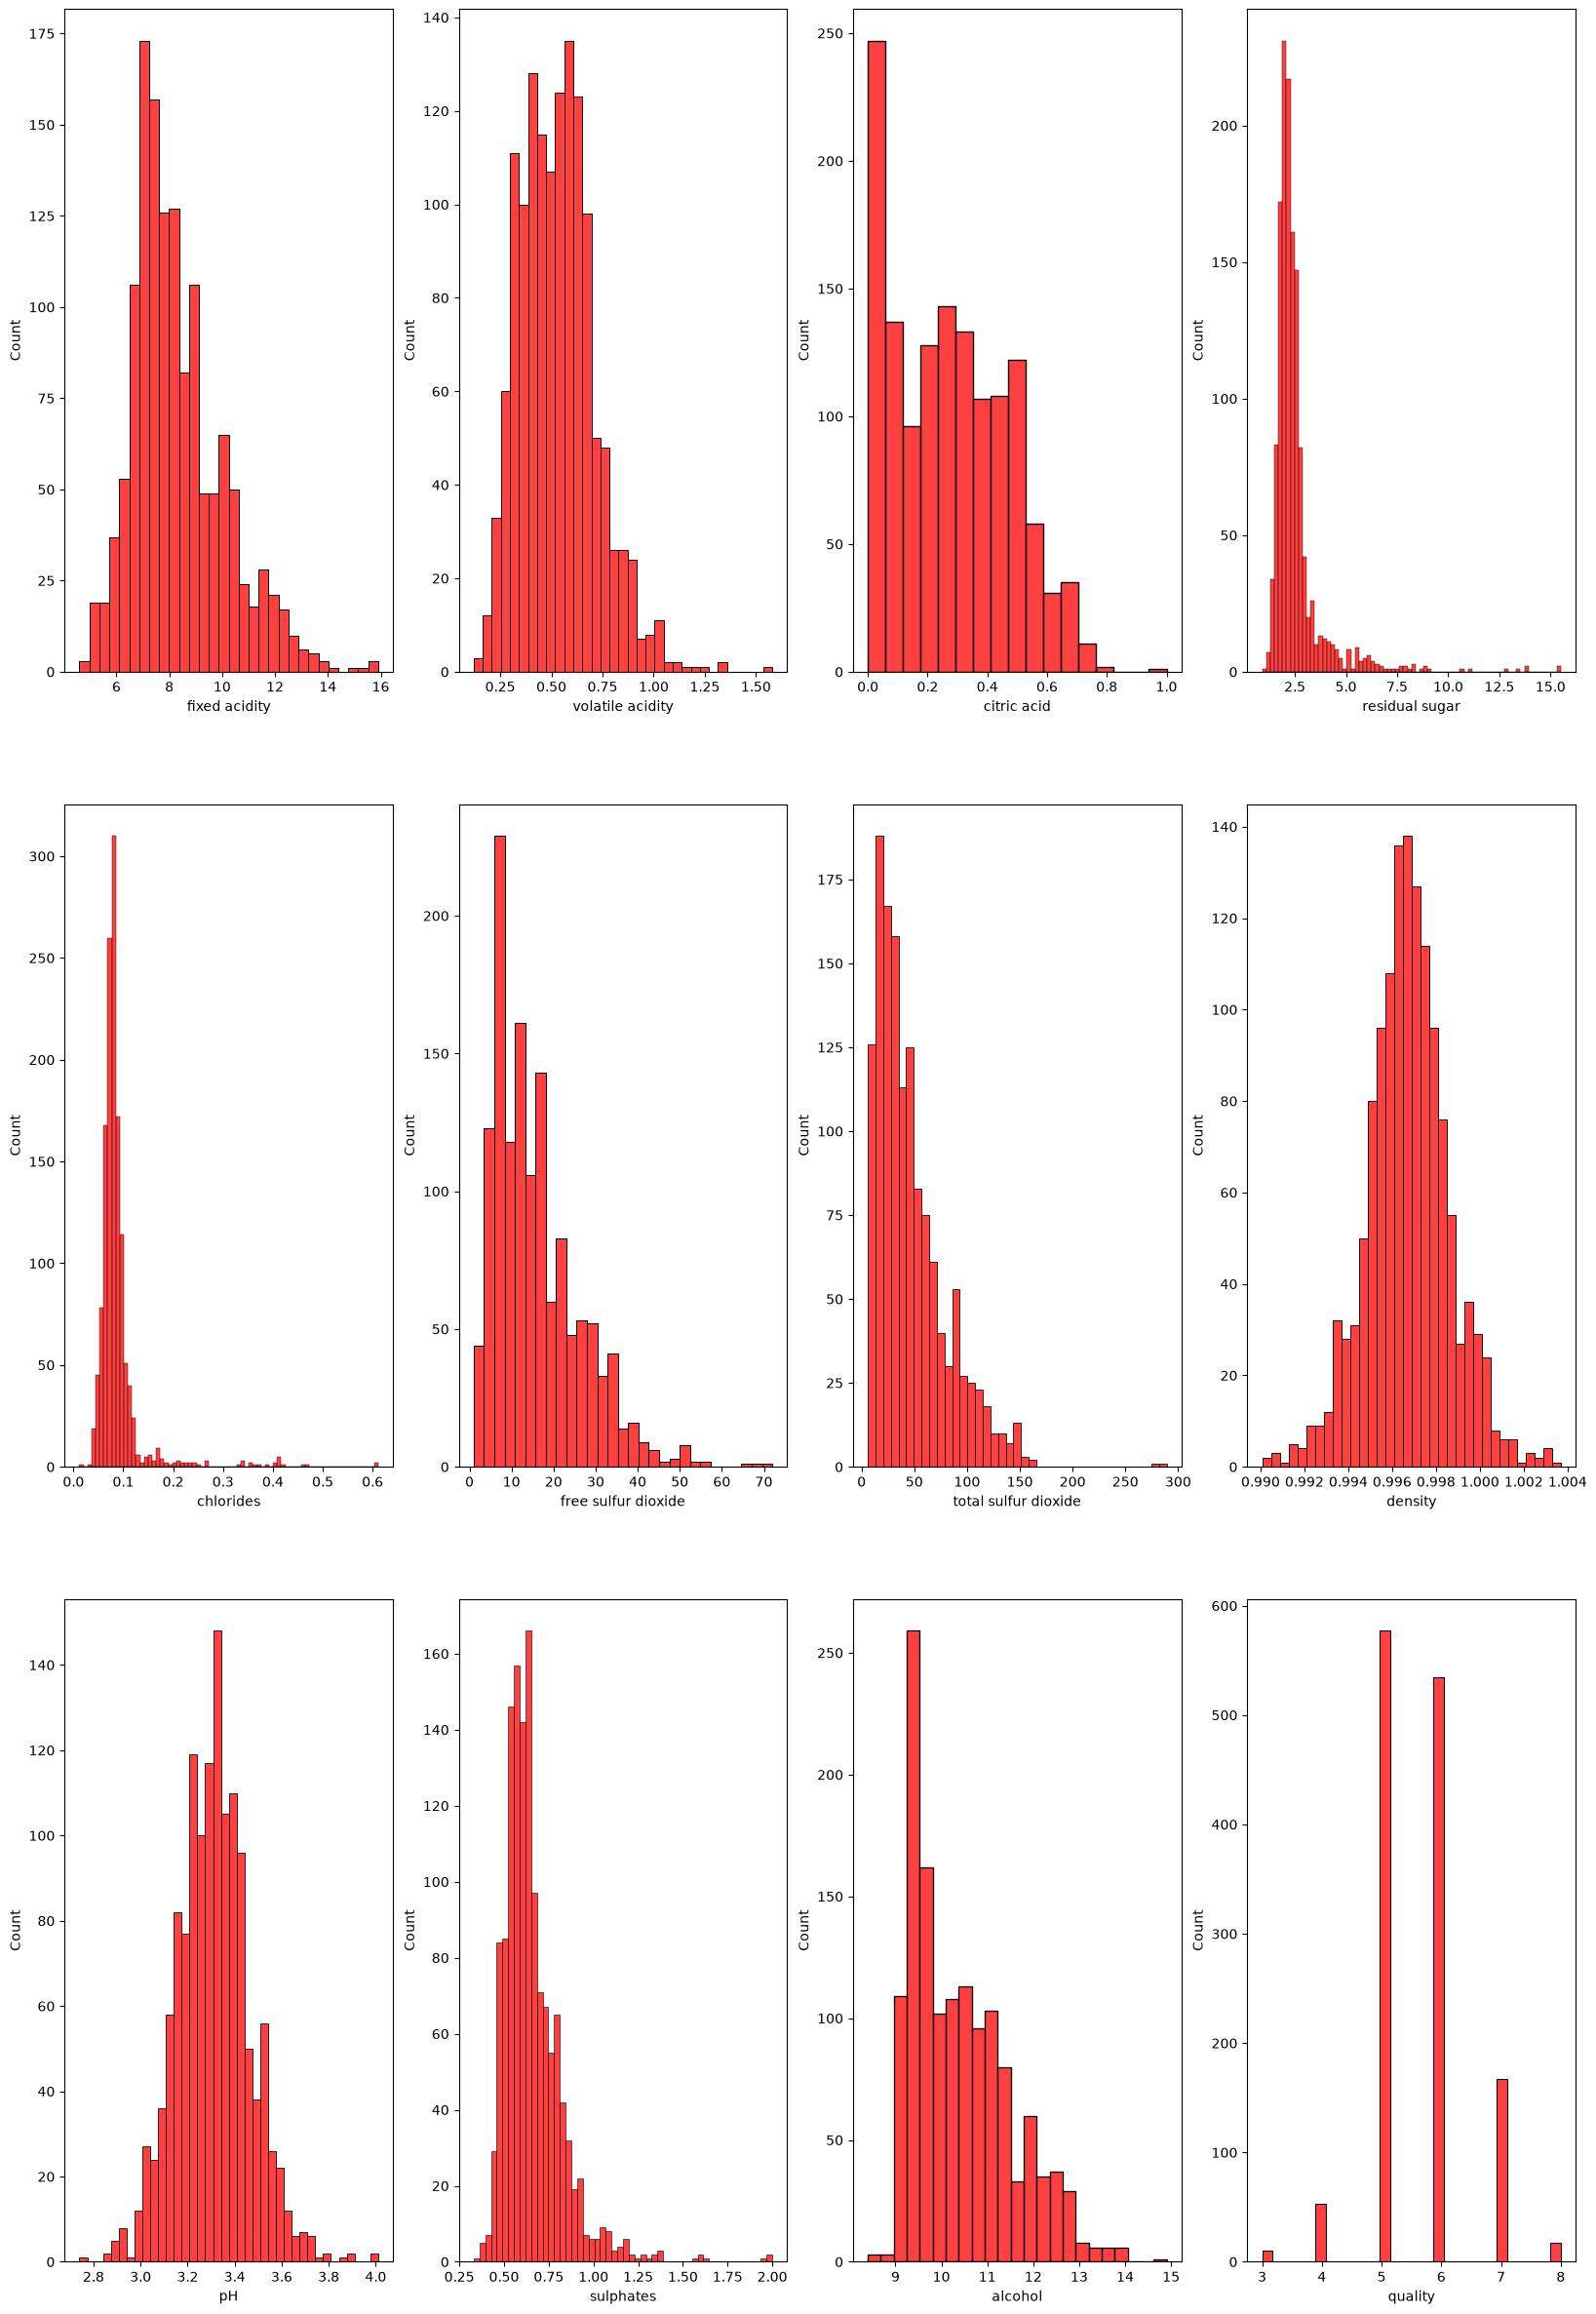

In [12]:
color = sns.color_palette("pastel")

fig, ax1 = plt.subplots(3,4, figsize=(20,30))
k = 0
columns = list(data.columns)
for i in range(3):
    for j in range(4):
            sns.histplot(data[columns[k]], ax = ax1[i][j], color = 'red')
            k += 1
plt.show()

In [13]:
data.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='str')

In [14]:
#apply log transform on the columns

data['residual sugar'] = np.log(data['residual sugar'])
data['chlorides'] = np.log(data['chlorides'])
data['free sulfur dioxide'] = np.log(data['free sulfur dioxide'])
data['total sulfur dioxide'] = np.log(data['total sulfur dioxide'])
data['sulphates'] = np.log(data['sulphates'])

In [15]:
data.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

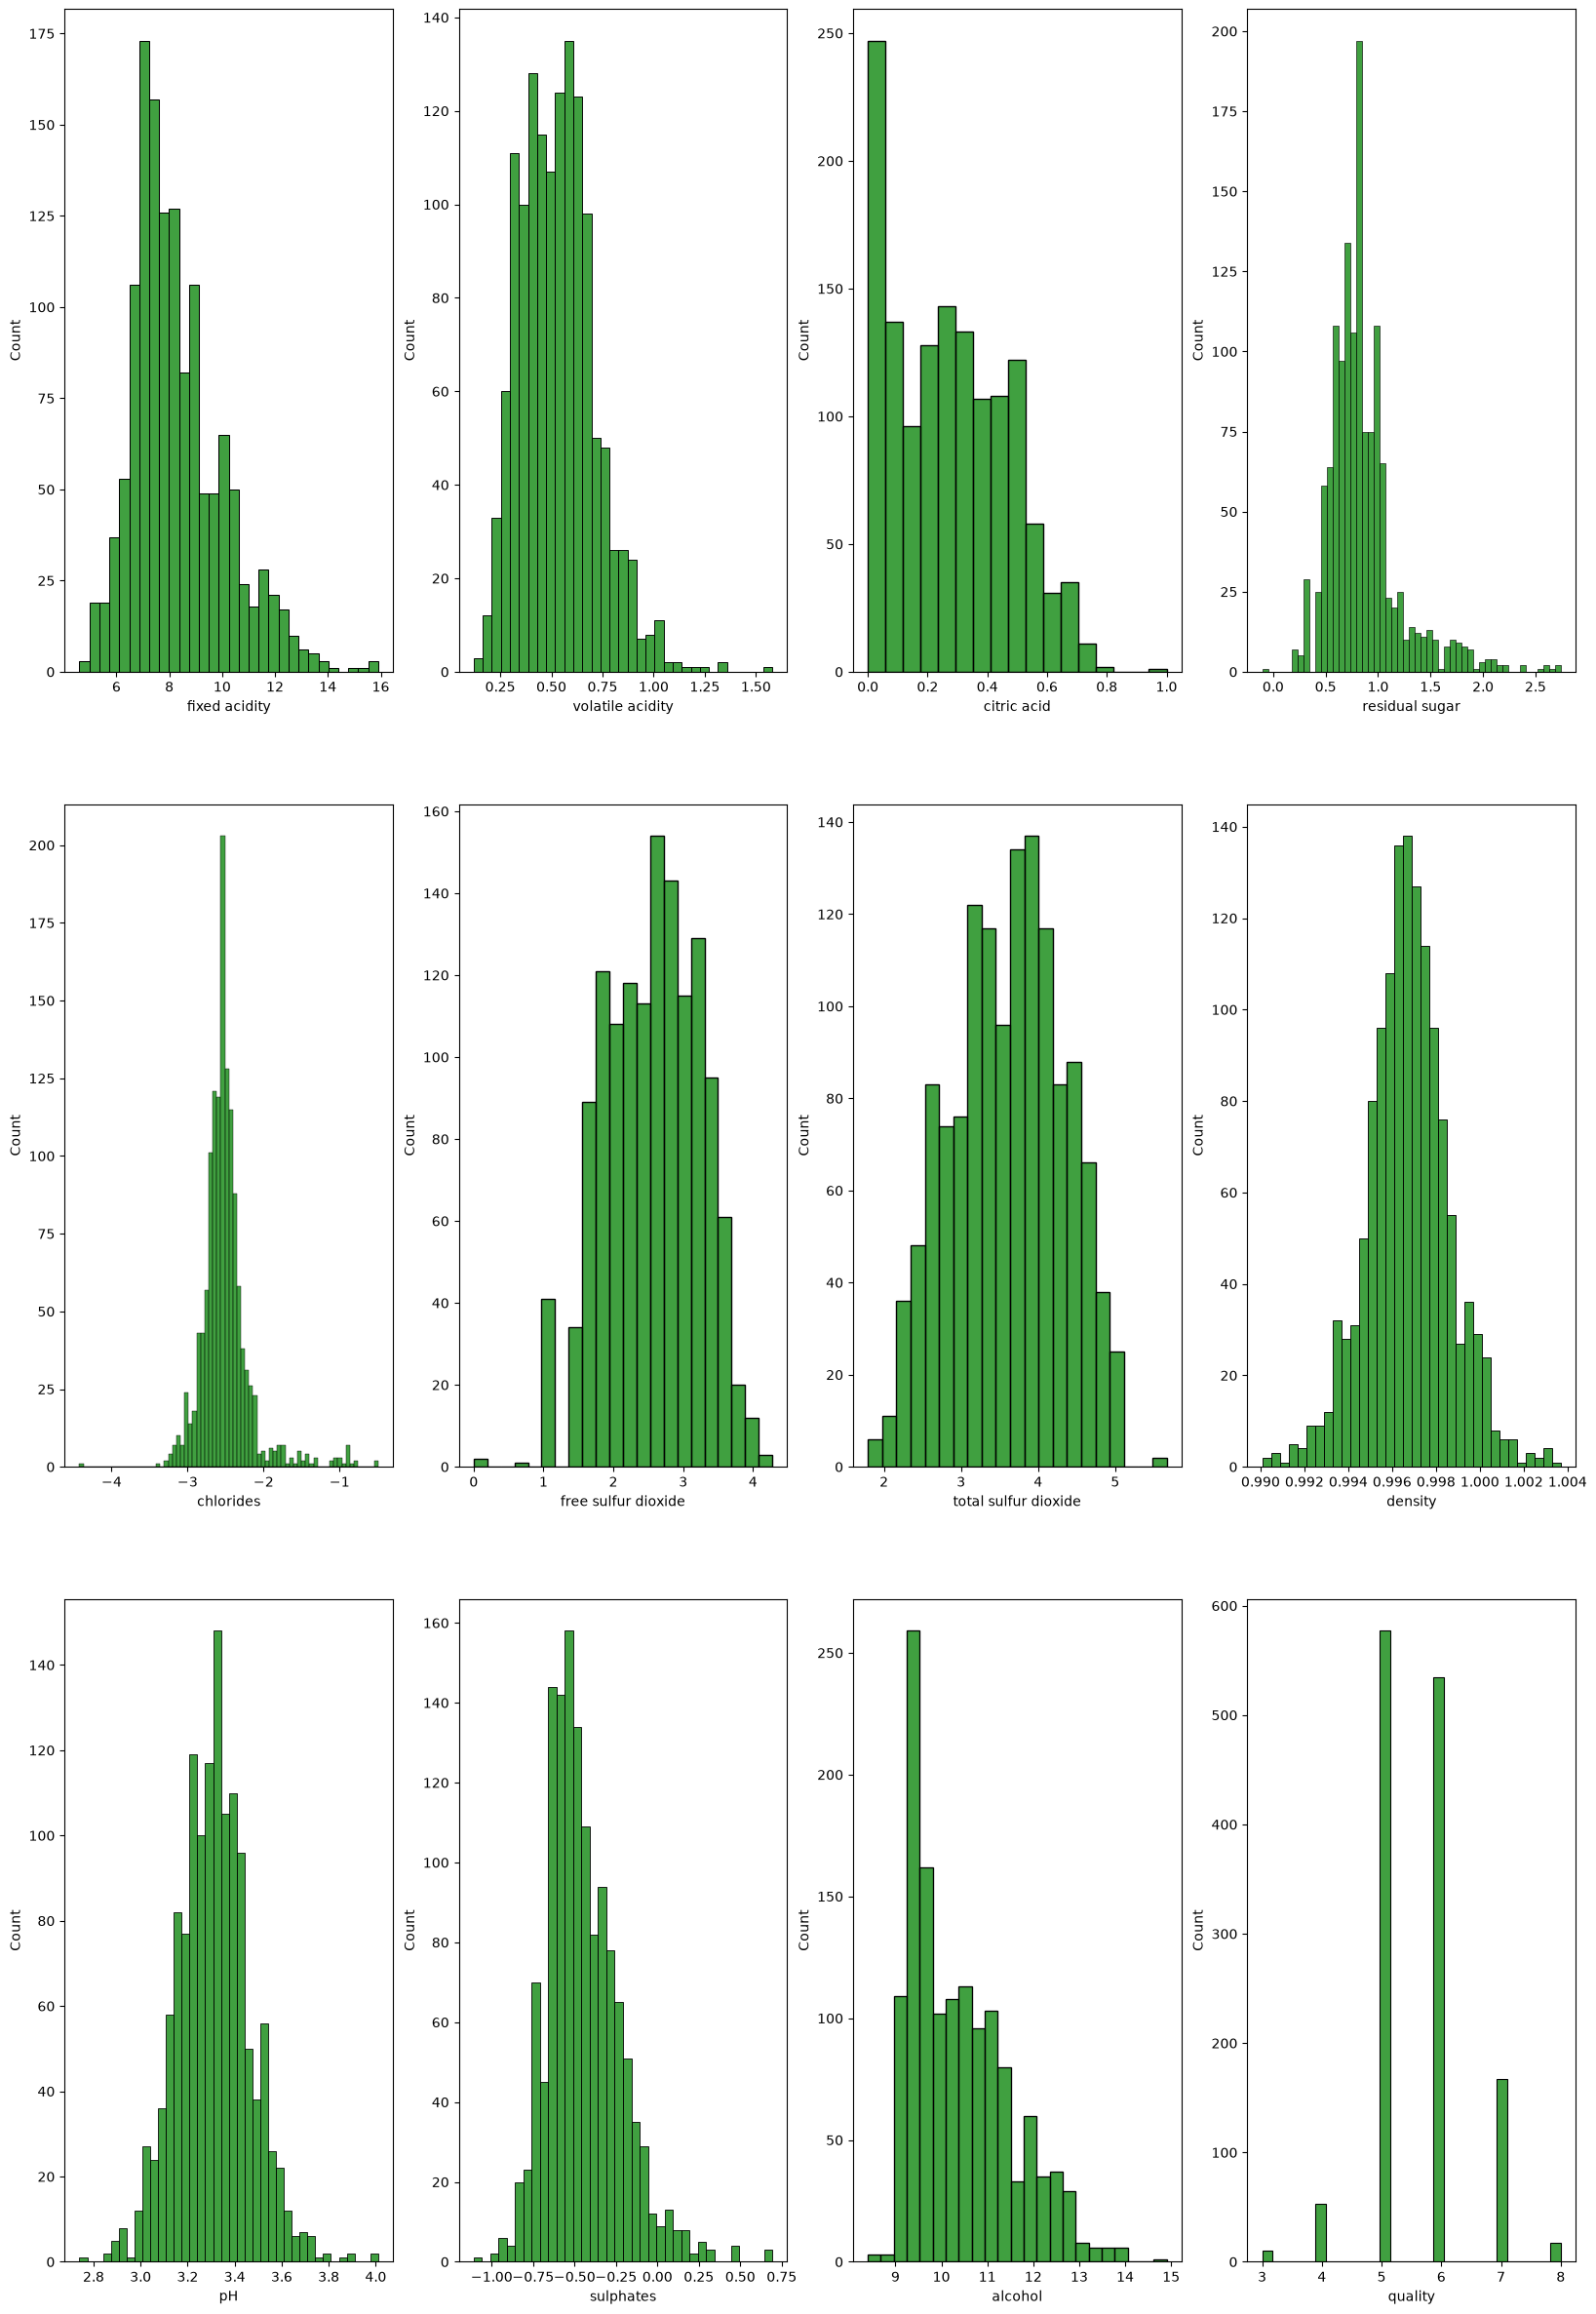

In [16]:
color = sns.color_palette("pastel")

fig, ax1 = plt.subplots(3,4, figsize=(20,30))
k = 0
columns = list(data.columns)
for i in range(3):
    for j in range(4):
            sns.histplot(data[columns[k]], ax = ax1[i][j], color = 'green')
            k += 1
plt.show()

In [17]:
# independent feature
X = data.drop('quality',axis='columns')
X.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,7.4,0.70,0.00,0.641854,-2.577022,2.397895,3.526361,0.9978,3.51,-0.579818,9.4
1,7.8,0.88,0.00,0.955511,-2.322788,3.218876,4.204693,0.9968,3.20,-0.385662,9.8
2,7.8,0.76,0.04,0.832909,-2.385967,2.708050,3.988984,0.9970,3.26,-0.430783,9.8
3,11.2,0.28,0.56,0.641854,-2.590267,2.833213,4.094345,0.9980,3.16,-0.544727,9.8
5,7.4,0.66,0.00,0.587787,-2.590267,2.564949,3.688879,0.9978,3.51,-0.579818,9.4


In [18]:
y= data['quality']
y.head()

0    5
1    5
2    5
3    6
5    5
Name: quality, dtype: int64

In [22]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2,random_state=0)
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((1087, 11), (272, 11), (1087,), (272,))

In [23]:




from imblearn.over_sampling import SMOTE
from collections import Counter

smote = SMOTE(random_state=42)

X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

print("After SMOTE:", Counter(y_resampled))

After SMOTE: Counter({5: 464, 7: 464, 6: 464, 4: 464, 8: 464, 3: 464})


In [24]:
# independent feature
X = data.drop('quality',axis='columns')
X.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,7.4,0.70,0.00,0.641854,-2.577022,2.397895,3.526361,0.9978,3.51,-0.579818,9.4
1,7.8,0.88,0.00,0.955511,-2.322788,3.218876,4.204693,0.9968,3.20,-0.385662,9.8
2,7.8,0.76,0.04,0.832909,-2.385967,2.708050,3.988984,0.9970,3.26,-0.430783,9.8
3,11.2,0.28,0.56,0.641854,-2.590267,2.833213,4.094345,0.9980,3.16,-0.544727,9.8
5,7.4,0.66,0.00,0.587787,-2.590267,2.564949,3.688879,0.9978,3.51,-0.579818,9.4


In [25]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2,random_state=0)
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((1087, 11), (272, 11), (1087,), (272,))

In [26]:
from imblearn.over_sampling import SMOTE
from collections import Counter

smote = SMOTE(random_state=42)

X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

print("After SMOTE:", Counter(y_resampled))

After SMOTE: Counter({5: 464, 7: 464, 6: 464, 4: 464, 8: 464, 3: 464})


In [27]:
X_resampled.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
count,2784.000000,2784.000000,2784.000000,2784.000000,2784.000000,2784.000000,2784.000000,2784.000000,2784.000000,2784.000000,2784.000000
mean,8.438549,0.578968,0.283609,0.851390,-2.497219,2.379871,3.363335,0.996543,3.318203,-0.445934,10.689219
std,1.665734,0.243368,0.192993,0.316903,0.319252,0.654604,0.653392,0.001884,0.142806,0.217742,1.219417
min,4.600000,0.120000,0.000000,0.182322,-4.422849,0.000000,1.791759,0.990200,2.740000,-1.108663,8.400000
25%,7.251594,0.395044,0.100000,0.650401,-2.672451,1.791759,2.833213,0.995259,3.227095,-0.598052,9.676075
50%,8.130327,0.540000,0.294297,0.776970,-2.551046,2.411939,3.332205,0.996567,3.312549,-0.461817,10.500000
75%,9.507558,0.700504,0.440000,0.955511,-2.389066,2.849076,3.856893,0.997860,3.397685,-0.292182,11.634810
max,15.600000,1.580000,1.000000,2.734368,-0.492658,4.276666,5.105945,1.003690,4.010000,0.693147,14.000000


In [28]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_fit = scaler.fit_transform(X_resampled)
X_test = scaler.transform(X_test)

In [29]:
X_train_fit_df = pd.DataFrame(X_train_fit, columns = X_resampled.columns)
X_train_fit_df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
count,2.784000e+03,2.784000e+03,2.784000e+03,2.784000e+03,2.784000e+03,2.784000e+03,2.784000e+03,2.784000e+03,2.784000e+03,2.784000e+03,2.784000e+03
mean,4.721638e-16,2.245968e-16,7.146263e-17,-1.276118e-18,-4.185668e-16,6.125368e-17,-1.020895e-16,2.168380e-14,-1.898864e-15,2.450147e-16,7.146263e-16
std,1.000180e+00,1.000180e+00,1.000180e+00,1.000180e+00,1.000180e+00,1.000180e+00,1.000180e+00,1.000180e+00,1.000180e+00,1.000180e+00,1.000180e+00
min,-2.304833e+00,-1.886242e+00,-1.469792e+00,-2.111653e+00,-6.032772e+00,-3.636240e+00,-2.405689e+00,-3.367936e+00,-4.049591e+00,-3.044196e+00,-1.877643e+00
25%,-7.126997e-01,-7.558824e-01,-9.515452e-01,-6.343429e-01,-5.489790e-01,-8.985843e-01,-8.114835e-01,-6.819641e-01,-6.380937e-01,-6.987425e-01,-8.309922e-01
50%,-1.850702e-01,-1.601486e-01,5.539256e-02,-2.348787e-01,-1.686343e-01,4.899696e-02,-4.765295e-02,1.235304e-02,-3.959918e-02,-7.296043e-02,-1.551997e-01
75%,6.418800e-01,4.994808e-01,8.104934e-01,3.286174e-01,3.388303e-01,7.169054e-01,7.555134e-01,6.990611e-01,5.566728e-01,7.062447e-01,7.755841e-01
max,4.300049e+00,4.113988e+00,3.712675e+00,5.942879e+00,6.280056e+00,2.898142e+00,2.667500e+00,3.794439e+00,4.845179e+00,5.232283e+00,2.715539e+00


# Logestic Regression

In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
model_lr = LogisticRegression()
model_lr.fit(X_train_fit, y_resampled)
y_predict_lr=model_lr.predict(X_test)
accuracy_lr = accuracy_score(y_test,y_predict_lr)
print(f"Accuracy pf LR:",round(accuracy_lr,2)*100,"%")

Accuracy pf LR: 45.0 %


In [32]:
from sklearn.svm import SVC
model_svc = SVC(kernel='rbf')
model_svc.fit(X_train_fit, y_resampled)
y_predict_svc=model_svc.predict(X_test)
accuracy_svc = accuracy_score(y_test,y_predict_svc)
print(f"Accuracy of SVC:",round(accuracy_svc,2)*100,"%")

Accuracy of SVC: 51.0 %


In [33]:
from sklearn.tree import DecisionTreeClassifier
model_dt = DecisionTreeClassifier()
model_dt.fit(X_train_fit, y_resampled)
y_predict_dt=model_dt.predict(X_test)
accuracy_dt = accuracy_score(y_test,y_predict_dt)
print(f"Accuracy of DT:",round(accuracy_dt,2)*100,"%")

Accuracy of DT: 44.0 %


In [34]:
from sklearn.neighbors import KNeighborsClassifier
model_knn =KNeighborsClassifier()
model_knn.fit(X_train_fit, y_resampled)
y_predict_knn=model_knn.predict(X_test)
accuracy_knn = accuracy_score(y_test,y_predict_knn)
print(f"Accuracy of KNN:",round(accuracy_knn,2)*100,"%")

Accuracy of KNN: 41.0 %


In [35]:
from sklearn.ensemble import RandomForestClassifier
model_rf =RandomForestClassifier()
model_rf.fit(X_train_fit, y_resampled)
y_predict_rf=model_rf.predict(X_test)
accuracy_rf= accuracy_score(y_test,y_predict_rf)
print(f"Accuracy of RF:",round(accuracy_rf,2)*100,"%")

Accuracy of RF: 53.0 %


# Random Forest

In [36]:
from sklearn.ensemble import RandomForestClassifier
model_rf =RandomForestClassifier()
model_rf.fit(X_train_fit, y_resampled)
y_predict_rf=model_rf.predict(X_test)
accuracy_rf= accuracy_score(y_test,y_predict_rf)
print(f"Accuracy of RF:",round(accuracy_rf,2)*100,"%")

Accuracy of RF: 56.00000000000001 %


In [37]:
# Save RF model and scaler parameters

import pickle

pickle.dump(model_rf, open('model_rf.pkl', 'wb'))
pickle.dump(scaler, open('scaler.pkl', 'wb'))